# 6.1 차원 축소 개요
- 차원 축소 : 다차원 데이터 세트의 차원 축소 -> 새로운 차원의 데이터 세트 생성
- 차원 증가 -> 데이터 포인트 간 거리 기하급수적으로 증가, 희소(sparse)한 구조 가짐 -> 예측 신뢰도 감소, 개별 피처 간 산관관계 높을 가능성 존재
## 피처 선택(feature selection)
- 특정 피처에 종속성 강한 불필요한 피처 제거, 주요 피처만 선택
## 피처 추출(feature extraction)
- 기존 피처를 저차원의 중요 피처로 입축해 추출
- 기존 피처와는 완전히 다른 값 됨 -> 단순한 합축이 아닌 피처를 함축적으로 더 잘 설명할 수 있는 또 다른 공간으로 매핑해 추출하는 것임
- 함축적인 특성 추출 : 기존 피처가 전혀 인지하기 어려웠던 잠재적인 요소 추출
## 대표적인 차원 축소 알고리즘 : PCA, SVD, NMF
- 변환된 이미지 : 분류 수행 시 과적합 영향력 작아져 예측 성능 올림(차원 수 작아지기에) : 차원 수 크면 비슷한 이미지더라도 적은 픽셀 차이로 잘못 예측 이뤄질 수 있기에
## 텍스트 문서의 숨겨진 의미 추출
- 문서 내 단어들의 구성에서 숨겨져 있는 시맨틱(sementic) 의미나 토픽(Topic)을 잠재 요소로 간주하고 찾아낼 수 있음
- SVD, NMF : 시맨틱 토픽 모델링을 위한 기반 알고리즘

# 6.2 PCA(Principal Component Analysis)
- 여러 변수 간에 존재하는 상관관계를 이용해 이를 대표하는 주성분(Principal Component)을 추출해 차원을 축소하는 기법
- 기존 데이터의 정보 유실 최소화 : 가장 높은 분산 가지는 데이터 축 찾아 이 축으로 차원 축소 진행(이 것이 주성분이 됨)
- 입력 데이터의 공분산 행렬이 고유벡터와 고유값으로 분해될 수 있으며 이렇게 분해된 고유벡터를 이용해 입력 데이터를 선형 변환하는 방식
### 첫번쨰 축
- 가장 큰 데이터 변동성(Variance)을 기반으로 생성
### 두번째 축
- 첫번째 축에 직각이 되는 벡터(직교 벡터)를 축으로 함
### 세번쨰 축
- 두번째 축에 직각이 되는 벡터 설정
### 생성된 벡터 축에 원본 데이터 투영
- 벡터 축의 개수만큼의 차원으로 원본 데이터가 차원 축소 됨
## 방식
- 입력 데이터 세트의 공분산 행렬을 생성
- 공분산 행렬의 고유벡터와 고유값을 계산
- 고유값이 가장 큰 순으로 K개(PCA 변환 차수만큼)만큼 고유벡터를 추출
- 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터를 변환

In [1]:
# 4개의 속성으로 되어 있는 붓꽃 데이터 세트를 2개의 PCA 차원으로 압축해 어떻게 달라졌는지 비교
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()
# 넘파이 데이터 세트를 판다스 DataFrame으로 변환
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns = columns)
irisDF['target'] = iris.target
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


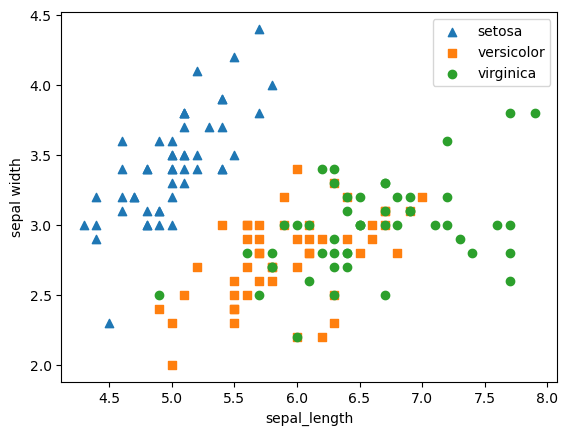

In [2]:
# 원본 데이터가 어떻게 분포 되어 있는지 2차원으로 시각화
# setosa는 세모, versicolor는 네모, virginica는 동그라미로 표현
markers = ['^', 's', 'o']

#setosa의 target 값는 0, versicolor는 1, virginica는 2. 각 target별로 다른 모양으로 산점도로 표시
for i, marker in enumerate(markers):
    x_axis_data = irisDF[irisDF['target']==i]['sepal_length']
    y_axis_data = irisDF[irisDF['target']==i]['sepal_width']
    plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])

plt.legend()
plt.xlabel('sepal_length')
plt.ylabel('sepal width')
plt.show()

- pca는 여러 속성의 값을 연산해야 하므로 속성의 스케일에 영향을 받음 -> pca 적용 전에 각 속성값을 동일한 스케일로 변환(스케일링) 필요

In [3]:
from sklearn.preprocessing import StandardScaler

# Target 값을 제외한 모든 속성 값을 StandardScaler를 이용해 표준 정규 분포를 가지는 값들로 변환
iris_scaled = StandardScaler().fit_transform(irisDF.iloc[:, :-1])

- pca를 적용해 4차원 붓꽃 데이터를 2차원 pca 데이터로 변환
- PCA 클래스는 생성 파라미터로 n_components(PCA로 변환할 차원의 수)를 입력 받음

In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

# fit()과 transform()을 호출해 PCA 변환 데이터 반환
pca.fit(iris_scaled) # fit(입력 데이터 세트)
iris_pca = pca.transform(iris_scaled) # transform(입력 데이터 세트)
print(iris_pca.shape)

(150, 2)


In [6]:
#  PCA 변환된 데이터의 갈럼명을 각각 pca_component_1, pca_component_2로 명명
pca_columns = ['pca_component_1', 'pca_component_2']
irisDF_pca = pd.DataFrame(iris_pca, columns = pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head(3)

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0


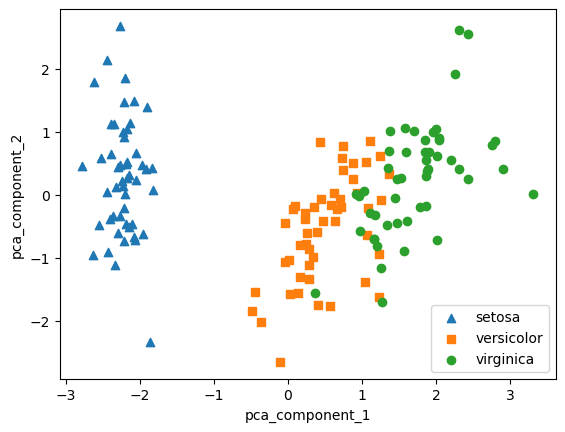

In [7]:
# setosa를 세모, versicolor를 네모, virginica를 동그라미로 표시
markers = ['^', 's', 'o']

# pca_component_1을 x축, pc_componet_2를 y축으로 scatter plot 수행
for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_1']
    y_axis_data = irisDF_pca[irisDF_pca['target']==i]['pca_component_2']
    plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()
# Setosa 명확하게 구분 / Versicolor와 Virginica는 pca_component_1 축 기반으로 겹치는 부분 일부 존재하지만 비교적 잘 구분됨
# 첫번째 새로운 축인 pca_component_1이 원본 데이터의 변동성을 잘 반영함

- PCA Component별로 원본 데이터의 변동성 얼마나 반영하는지

In [8]:
print(pca.explained_variance_ratio_) # 전체 변동성에서 개별 PCA 컴포넌트별로 차지하는 변동성 비율 제공
# 2개의 요소로만 변환해도 원본 데이터의 변동성 95% 설명 가능

[0.72962445 0.22850762]


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

rcf = RandomForestClassifier(random_state = 156)
scores = cross_val_score(rcf, iris.data, iris.target, scoring = 'accuracy', cv = 3)
print('원본 데이터 교차 검증 개별 정확도 : ', scores)
print('원본 데이터 평균 정확도 : ', np.mean(scores))

원본 데이터 교차 검증 개별 정확도 :  [0.98 0.94 0.96]
원본 데이터 평균 정확도 :  0.96


In [13]:
pca_X = irisDF_pca[['pca_component_1', 'pca_component_2']]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring = 'accuracy', cv = 3)
print('PCA 변환 데이터 교차 검증 개별 정확도 : ', scores_pca)
print('PCA 변환 데이터 평균 정확도 : ', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도 :  [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도 :  0.88


In [20]:
pip install xlrd # excel 파일 읽울 수 있게

Note: you may need to restart the kernel to use updated packages.


In [25]:
# header로 의미 없는 첫 행 제거, iloc로 기존 id 제거
import pandas as pd

df = pd.read_excel("C:\\Users\\user\\Downloads\\default+of+credit+card+clients\\pca_credit_card.xls", header = 1, sheet_name = 'Data').iloc[0:,1:]
print(df.shape)
df.head(3)

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [26]:
# default payment next month이 target 값 연체 1, 정상납부 0
df.rename(columns = {'PAY_0':'PAY_1', 'default payment next month':'default'}, inplace = True)
y_target = df['default']
X_features = df.drop('default', axis = 1)

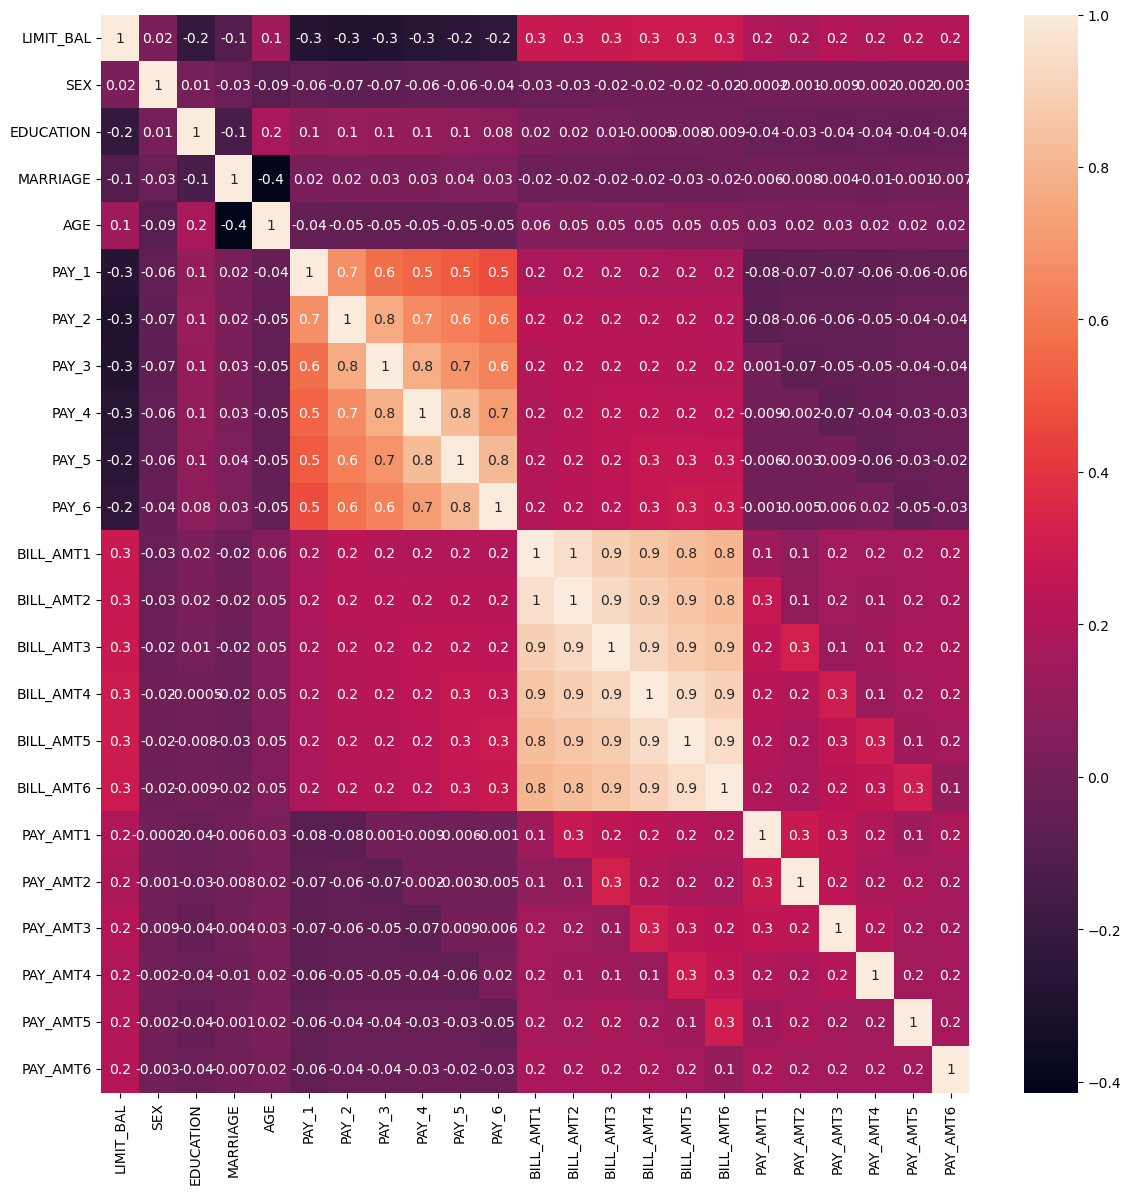

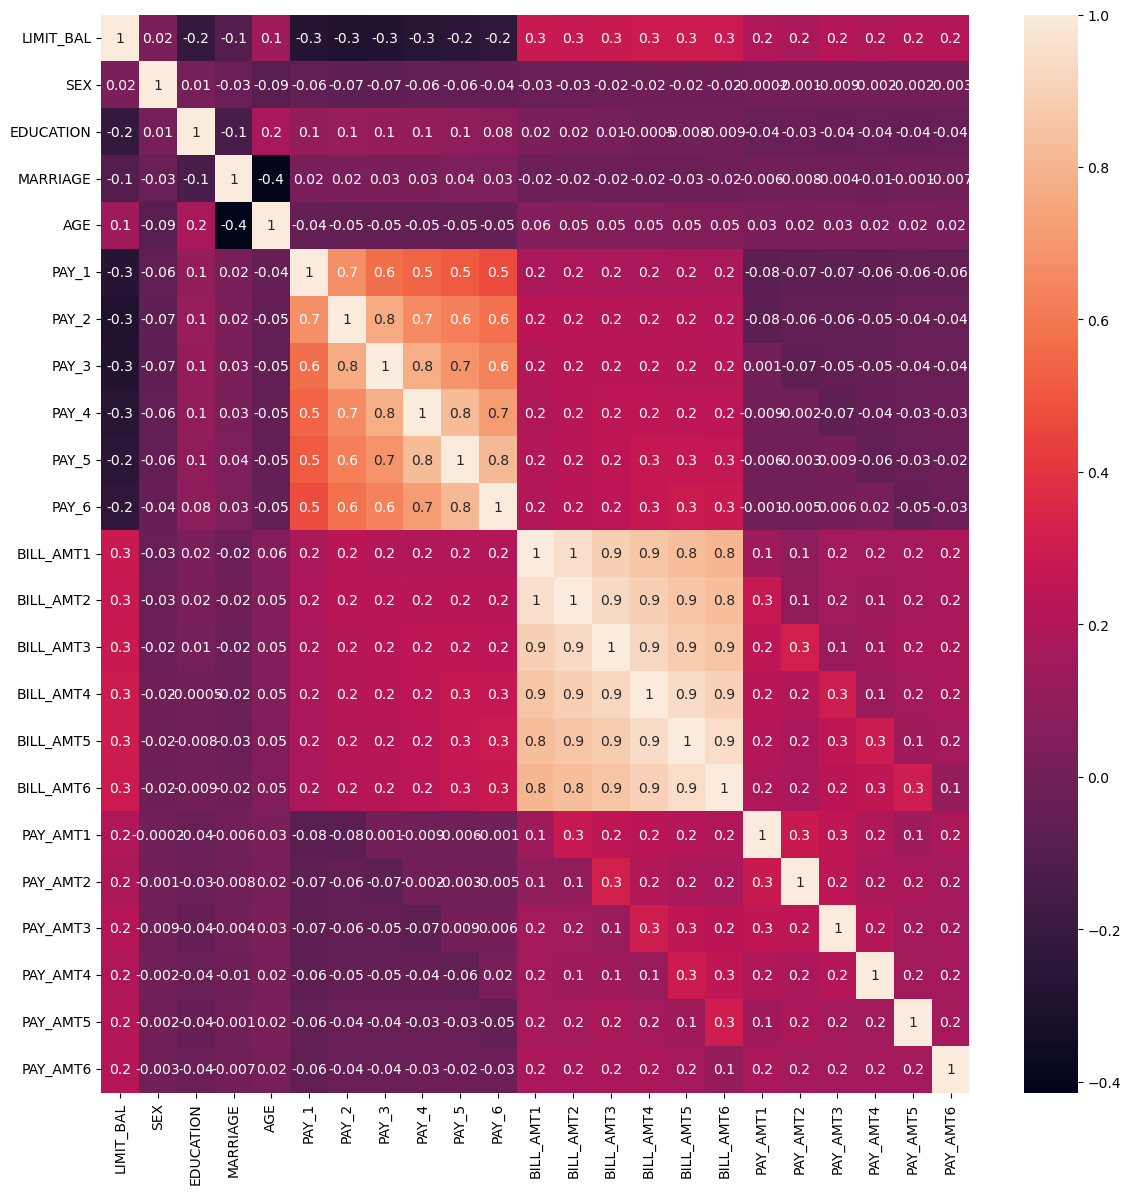

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

corr = X_features.corr()
plt.figure(figsize=(14,14))
sns.heatmap(corr, annot = True, fmt = '.1g')
plt.show()

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# BILL_AMT1 ~ BILL_AMT6까지 6개의 속성명 생성
cols_bill = ['BILL_AMT'+str(i) for i in range(1, 7)]
print('대상 속성명 : ', cols_bill)

# 2개의 PCA 속성을 가진 PCA 객체 생성하고, explained_variance_ratio_ 계산을 위해 fit() 호출
scaler = StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])
pca = PCA(n_components = 2)
pca.fit(df_cols_scaled)
print('PCA Component별 변동성 : ', pca.explained_variance_ratio_)

대상 속성명 :  ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PCA Component별 변동성 :  [0.90555253 0.0509867 ]


In [33]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(n_estimators = 300, random_state = 156)
scores = cross_val_score(rcf, X_features, y_target, scoring = 'accuracy', cv = 3)

print('CV = 3인 경우의 개별 Fold 세트별 정확도 : ', scores)
print('평균 정확도 :{0:.4f}'.format(np.mean(scores)))

CV = 3인 경우의 개별 Fold 세트별 정확도 :  [0.8083 0.8196 0.8232]
평균 정확도 :0.8170


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X_features)

# 6개의 컴포넌트를 가진 PCA 변환을 수행하고 cross_val_score() 로 분류 예측 수행.
pca = PCA(n_components = 6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf, df_pca, y_target, scoring = 'accuracy', cv = 3)

print('CV = 3인 경우의 PCA 변환된 개별 Fold 세트별 정확도 : ', scores_pca)
print('PCA 변환 데이터 세트 평균 정확도 : {0:.4f}'.format(np.mean(scores_pca)))

CV = 3인 경우의 PCA 변환된 개별 Fold 세트별 정확도 :  [0.7912 0.7974 0.802 ]
PCA 변환 데이터 세트 평균 정확도 : 0.7969


# 6.3 LDA(Linear Discriminat Analysis) : 선형 판별 분석법
- PCA와 유사하게 입력 데이터 세트를 저차원 공간에 투영해 차원을 축소하는 기법
- 차이점 : LDA는 지도학습의 분류(Classification)에서 사용하기 쉽도록 개별 클래스를 분별할 수 있는 기준을 최대한 유지하면서 차원을 축소함
- 입력 데이터의 겨렁 값 클래스를 최대한으로 분리할 수 있는 축 찾음
### 방식
- 클래스 간 분산과 클래스 내부 분산의 비율을 최대화하는 방식으로 차원을 축소함(클래스 간 분산은 최대한 크게, 클래스 내부 분산은 최대한 작게)
### 스텝
- 클래스 내부와 클래스 간 분산 행렬 구함, 이 두 개의 행렬은 입력 데이터의 결정 값 클래스별로 개별 피처의 팽균 벡터를 기반으로 구함
- 클래스 내부 분산 행렬을 Sw, 클래스 간 분산 행렬을 Sb라고 하면 다음 식으로 두 행렬을 고유벡터로 분해 가능 p.416
- 고유값이 가장 큰 순으로 K개(LDA 변환 차수 만큼) 추출
- 고유값이 가장 큰 순으로 추출된 고유벡터를 이용해 새롭게 입력 데이터 변환

In [37]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data) # 클래스의 결정값이 변환 시 필요 / fit() 메서드를 호출해 결정값 입력

In [39]:
lda = LinearDiscriminantAnalysis(n_components = 2)
lda.fit(iris_scaled, iris.target)
iris_lda = lda.transform(iris_scaled)
print(iris_lda.shape)

(150, 2)


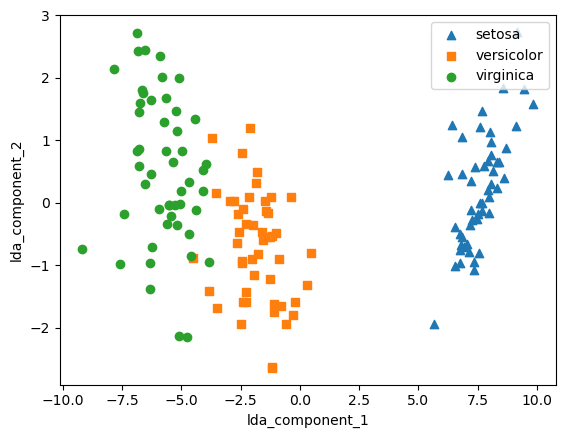

In [63]:
lda_columns = ['lda_component_1', 'lda_component_2']
irisDF_lda = pd.DataFrame(iris_lda, columns = lda_columns)
irisDF_lda['target'] = iris.target

# setosa는 세모, versicolor는 네모, virginica는 동그라미로 표현
markers = ['^', 's', 'o']

# setosa의 target 값은 0, versicolor는 1, virginica는 2. 각 target 별로 다른 모양으로 산점도로 표시
for i, marker in enumerate(markers):
    x_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda_component_1']
    y_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda_component_2']

    plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])

plt.legend(loc = 'upper right')
plt.xlabel('lda_component_1')
plt.ylabel('lda_component_2')
plt.show()
# PCA로 변환된 데이터와 좌우 대칭 형태로 많이 닮아있음

# 6.4 SVD(Singular Value Decomposition) : 특이값 분해
- PCA와 유사한 행렬 분해 기법 사용 but, 정방행렬 뿐만 아니라 행과 열의 크기가 다른 행렬에도 적용가능
- 특이벡터(singular vector) : 행렬 U와 V에 속한 벡터 / 서로 직교하는 성질 가짐
- 특이값 : 대각행렬이 위치한 0이 아닌 값
### Truncated SVD
- 시그마의 대각원소 중에 상위 몇개만 추출해서 여기에 대응하는 U와 V의 원소도 함께 제거해 더욱 차원을 줄인 형태로 분해하는 것

In [43]:
# 넘파이의 svd 모듈 임포트
import numpy as np
from numpy.linalg import svd

# 4x4 랜덤 행렬 a 생성 : 행렬의 개별 로우끼리의 의존성 없애기 위해
np.random.seed(121)
a = np.random.randn(4, 4)
print(np.round(a, 3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


In [44]:
# SVD 분해는 numpy.linalg.svd에 파라미터로 원본 행렬을 입력하면 U, Sigma 행렬, V 전치 행렬 반환함
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('U matrix : \n', np.round(U, 3))
print('Sigma Value : \n', np.round(Sigma, 3))
print('V transpose matrix : \n', np.round(Vt, 3))

(4, 4) (4,) (4, 4)
U matrix : 
 [[-0.079 -0.318  0.867  0.376]
 [ 0.383  0.787  0.12   0.469]
 [ 0.656  0.022  0.357 -0.664]
 [ 0.645 -0.529 -0.328  0.444]]
Sigma Value : 
 [3.423 2.023 0.463 0.079]
V transpose matrix : 
 [[ 0.041  0.224  0.786 -0.574]
 [-0.2    0.562  0.37   0.712]
 [-0.778  0.395 -0.333 -0.357]
 [-0.593 -0.692  0.366  0.189]]


In [45]:
# 원본 행렬로의 복원(내적 통해)
# Sigma를 다시 0을 포함한 대칭행렬로 변환
Sigma_mat = np.diag(Sigma)
a_ = np.dot(np.dot(U, Sigma_mat), Vt)
print(np.round(a_, 3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.014  0.63   1.71  -1.327]
 [ 0.402 -0.191  1.404 -1.969]]


### 데이터 세트가 로우 간 의존성이 있을 경우 어떻게 sigma 값이 변하고, 이에 따른 차원 축소가 진행될 수 있는지 알아보기

In [46]:
# 의존성 있는 행렬로 만들기
a[2] = a[0] + a[1]
a[3] = a[0]
print(np.round(a, 3))

[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


In [48]:
# 다시 SVD를 수행해 Sigma 값 확인
U, Sigma, Vt = svd(a)
print(U.shape, Sigma.shape, Vt.shape)
print('Sigma Value:\n', np.round(Sigma, 3))
# 이전과 차원은 동일하지만 Sigma 값 중 2개 0으로 변함 : 선형 독립인 로우 벡터의 개수가 2개(행렬의 랭크 2)

(4, 4) (4,) (4, 4)
Sigma Value:
 [2.663 0.807 0.    0.   ]


In [49]:
# U 행렬의 경우는 Sigma와 내적을 수행하므로 Sigma의 앞 2행에 대응되는 앞 2열만 추출
U_ = U[:, :2]
Sigma_ = np.diag(Sigma[:2])
# V 전치 행렬의 경우는 앞 2행만 추출
Vt_ = Vt[:2]
print(U_.shape, Sigma_.shape, Vt_.shape)
# U, Sigma, Vt의 내적을 수행하며, 다시 원본 행렬 복원
a_ = np.dot(np.dot(U_, Sigma_), Vt_)
print(np.round(a_, 3))

(4, 2) (2, 2) (2, 4)
[[-0.212 -0.285 -0.574 -0.44 ]
 [-0.33   1.184  1.615  0.367]
 [-0.542  0.899  1.041 -0.073]
 [-0.212 -0.285 -0.574 -0.44 ]]


### Truncate SVD를 이용해 행렬 분해

In [1]:
import numpy as np
from scipy.sparse.linalg import svds
from scipy.linalg import svd

# 원본 행렬을 출력하고 SVD를 적용할 경우 U, Sigma, Vt의 차원 확인
np.random.seed(121)
matrix = np.random.random((6, 6))
print('원본 행렬 :\n', matrix)
U, Sigma, Vt = svd(matrix, full_matrices = False)
print('\n분해 행렬 차원 : ', U.shape, Sigma.shape, Vt.shape)
print('\nSigma 값 행렬 : ', Sigma)

# Truncated SVD로 Sigma 행렬의 특이값을 4개로 하여 Truncated SVD 수행
num_components = 4
U_tr, Sigma_tr, Vt_tr = svds(matrix, k = num_components)
print('\nTruncated SVD 분해 행렬 차원 : ', U_tr.shape, Sigma_tr.shape, Vt_tr.shape)
print('\nTruncated SVD Sigma 갑 행렬 : ', Sigma_tr)
matrix_tr = np.dot(np.dot(U_tr, np.diag(Sigma_tr)), Vt_tr) # output of TruncatedSVD

print('\nTruncated SVD로 분해 후 복원 행렬 : \n', matrix_tr)

원본 행렬 :
 [[0.11133083 0.21076757 0.23296249 0.15194456 0.83017814 0.40791941]
 [0.5557906  0.74552394 0.24849976 0.9686594  0.95268418 0.48984885]
 [0.01829731 0.85760612 0.40493829 0.62247394 0.29537149 0.92958852]
 [0.4056155  0.56730065 0.24575605 0.22573721 0.03827786 0.58098021]
 [0.82925331 0.77326256 0.94693849 0.73632338 0.67328275 0.74517176]
 [0.51161442 0.46920965 0.6439515  0.82081228 0.14548493 0.01806415]]

분해 행렬 차원 :  (6, 6) (6,) (6, 6)

Sigma 값 행렬 :  [3.2535007  0.88116505 0.83865238 0.55463089 0.35834824 0.0349925 ]

Truncated SVD 분해 행렬 차원 :  (6, 4) (4,) (4, 6)

Truncated SVD Sigma 갑 행렬 :  [0.55463089 0.83865238 0.88116505 3.2535007 ]

Truncated SVD로 분해 후 복원 행렬 : 
 [[0.19222941 0.21792946 0.15951023 0.14084013 0.81641405 0.42533093]
 [0.44874275 0.72204422 0.34594106 0.99148577 0.96866325 0.4754868 ]
 [0.12656662 0.88860729 0.30625735 0.59517439 0.28036734 0.93961948]
 [0.23989012 0.51026588 0.39697353 0.27308905 0.05971563 0.57156395]
 [0.83806144 0.78847467 0.9386868

### 사이킷런 Truncated SVD 클래스를 이용한 변환
- PCA와 유사하게 fit() 와 transform()을 호출해 원보 ㄴ데이터를 TRuncated SVD 방식으로 분해된 U*Sigma 행렬에 선형 변환해 생성

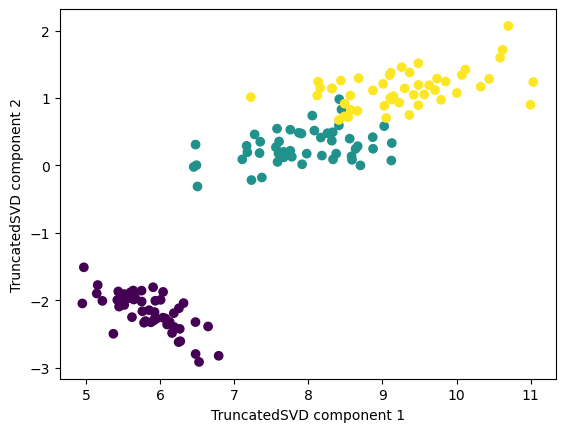

In [56]:
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

iris = load_iris()
iris_ftrs = iris.data
# 2개의 주요 컴포넌트로 TruncatedSVD 변환
tsvd = TruncatedSVD(n_components = 2)
tsvd.fit(iris_ftrs)
iris_tsvd = tsvd.transform(iris_ftrs)

# 산점도 2차원으로 TruncatedSVD 변환된 데이터 표현. 품종은 색깔로 구분
plt.scatter(x = iris_tsvd[:, 0], y = iris_tsvd[:, 1], c = iris.target)
plt.xlabel('TruncatedSVD component 1')
plt.ylabel('TruncatedSVD component 2')
plt.show()

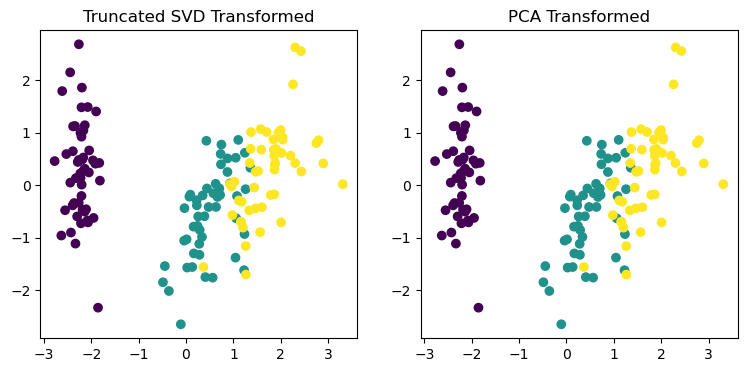

In [60]:
# 붓꽃 데이터를 StandardScaler로 변환
sclaer = StandardScaler()
iris_scaled = scaler.fit_transform(iris_ftrs)

# 스케일링된 데이터를 기반으로 TruncatedSVD 변환 수행
tsvd = TruncatedSVD(n_components = 2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)

# 스케일링된 데이터를 기반으로 PCA 변환 수행
pca = PCA(n_components = 2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

# TruncatedSVD 변환 데이터를 왼쪽에, PCA 변환 데이터를 오른쪽에 표현
fig, (ax1, ax2) = plt.subplots(figsize = (9, 4), ncols = 2)
ax1.scatter(x = iris_tsvd[:, 0], y = iris_tsvd[:, 1], c = iris.target)
ax2.scatter(x = iris_pca[:, 0], y = iris_pca[:, 1], c = iris.target)
ax1.set_title('Truncated SVD Transformed')
ax2.set_title('PCA Transformed')
plt.show()

In [61]:
print((iris_pca - iris_tsvd).mean())
print((pca.components_ - tsvd.components_).mean())
# 데이터 세트가 스케일링으로 데이터 중심이 동일해지면 사이킷런의 SVD와 PCA는 동일한 변환을 수행
# but, PCA는 밀집 행렬에 대한 변환만 가능한데 반해 SVD는 희소 행렬에 대한 변환도 가능

2.342183160382779e-15
6.938893903907228e-18
